## 11.09节练习参考答案

## 环境准备

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from src.utils import *

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)。

### 练习11.9.1
调整$\rho$的值，会发生什么？

**解答：**

In [2]:
def init_adadelta_states(feature_dim):
    s_w, s_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    delta_w, delta_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    return ((s_w, delta_w), (s_b, delta_b))

def adadelta(params, states, hyperparams):
    rho, eps = hyperparams['rho'], 1e-5
    for p, (s, delta) in zip(params, states):
        with torch.no_grad():
            # In-placeupdatesvia[:]
            s[:] = rho * s + (1 - rho) * torch.square(p.grad)
            g = (torch.sqrt(delta + eps) / torch.sqrt(s + eps)) * p.grad
            p[:] -= g
            delta[:] = rho * delta + (1 - rho) * g * g
        p.grad.data.zero_()

loss: 0.247, 0.012 sec/epoch


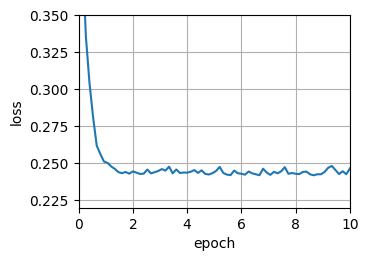

In [3]:
data_iter, feature_dim = get_data_ch11(batch_size=10)
train_ch11(adadelta,
        init_adadelta_states(feature_dim),
        {'rho': 0.9},
        data_iter, feature_dim, num_epochs=10);

# 直接调用torch的api
# trainer = torch.optim.Adadelta
# train_concise_ch11(trainer, {'rho': 0.5}, data_iter)

loss: 0.244, 0.012 sec/epoch


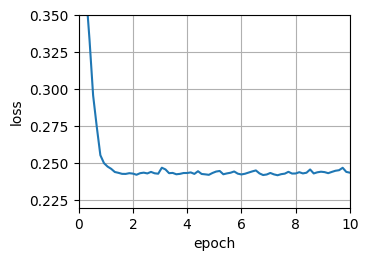

In [4]:
train_ch11(adadelta,
        init_adadelta_states(feature_dim),
        {'rho': 0.6},
        data_iter, feature_dim, num_epochs=10);

loss: 0.244, 0.011 sec/epoch


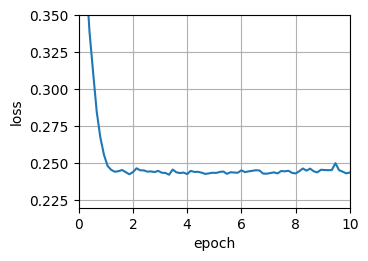

In [5]:
train_ch11(adadelta,
        init_adadelta_states(feature_dim),
        {'rho': 0.3},
        data_iter, feature_dim, num_epochs=10);

- 在这个数据集上参数 $\rho$ 的影响不大，loss均收敛。

$\rho$ 实则控制了优化时当前梯度和历史梯度的比例，当 $\rho$ 值越大，调整后梯度会更多地倾向于历史梯度；当 $\rho$ 值越小，调整后梯度会更多地倾向于当前梯度。

事实上，当 $\rho$ 越大，变化量衰减的速度就越慢；当 $\rho$ 越小，变化率衰减的速度就越快。

### 练习11.9.2
展示如何在不使用$\mathbf{g}_t'$的情况下实现算法。为什么这是个好主意？

**解答：**

$\boldsymbol{g}_t'=\sqrt{\dfrac{\Delta\boldsymbol{x}_{t-1}+\epsilon}{\boldsymbol{s}_t+\epsilon}}\odot\boldsymbol{g}_t$ 是缩放后的更新方向。可不显式存储它，把缩放因子直接并入参数与 $\Delta\boldsymbol{x}$ 的更新：

$$\boldsymbol{x}_t=\boldsymbol{x}_{t-1}-\sqrt{\dfrac{\Delta\boldsymbol{x}_{t-1}+\epsilon}{\boldsymbol{s}_t+\epsilon}}\odot\boldsymbol{g}_t,$$

$$\Delta\boldsymbol{x}_t=\rho\,\Delta\boldsymbol{x}_{t-1}+(1-\rho)\,\dfrac{\Delta\boldsymbol{x}_{t-1}+\epsilon}{\boldsymbol{s}_t+\epsilon}\odot\boldsymbol{g}_t^{\,2}.$$

好处是无需为 $\boldsymbol{g}_t'$ 单独分配缓冲，省去中间变量的存储与读写。

### 练习11.9.3
Adadelta真的是学习率为0吗？能找到Adadelta无法解决的优化问题吗？

**解答：**

- Adadelta算法中的学习率并不是固定为0。对于Adadelta算法，学习率是动态调整的，并且不需要手动设置一个固定的学习率值。

Adadelta算法维护一个状态变量来存储这个指数移动平均值，并使用该变量来计算每个参数更新的学习率。

Adadelta 不能解决的优化问题包括：

1. **高度非凸问题**：Adadelta是基于梯度信息的自适应学习率算法。在高度非凸的优化问题中，梯度可能会变化非常剧烈，导致Adadelta难以适应这种剧烈变化。相比之下，一些更复杂的优化算法，如具有动量的随机梯度下降（SGD with momentum）或Adam可能能更好地处理这种情况。

2. **离散优化问题**：Adadelta假设参数的连续更新，而在离散优化问题中，参数可能只能取离散的值。这种情况下，Adadelta可能不是最适合的选择。在离散优化问题中，特定的优化算法，如遗传算法或模拟退火等可能更适合。

3. **奇异性质的问题**：一些优化问题可能具有奇异性质，即梯度在某些点上可能不存在或变得非常大。这种情况下，Adadelta可能会遇到数值稳定性的问题，因为它涉及梯度的平方根。其他一些优化算法可能会采取特殊的处理方式来处理奇异点。

### 练习11.9.4
将Adadelta的收敛行为与AdaGrad和RMSProp进行比较。

**解答：**

- AdaGrad 会自适应地调整学习率，使稀疏特征对应的参数具有较大的学习率，但是可能会在后期过早停止学习，因为梯度的平方和随时间增加，导致学习率变得很小，减缓了参数更新的速度；

- 而RMSProp 就是针对这一问题做出了优化，引入指数加权移动平均来平滑梯度的历史平方和，减缓了学习率的衰减，对学习率的适应性更好，能够更稳定地收敛到最优解；

- AdaDelta 则是在 RMSProp 上做出进一步改进，避免了手动设置学习率，通常能更稳定地收敛到最优解，而且避免了手动调整学习率可能导致的参数不正确带来的不收敛。